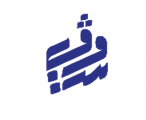
#  **Notebook d'Analyse de Qualité des Donnée(Data Quality)**
# **Sujet : E-Commerce Sougui Shop**

# Data Quality – Projet BI E-commerce

Objectif :
 1. Importer des données depuis différents formats (PDF, Excel, CSV, XML, etc.)
 2. Analyser la qualité des données selon plusieurs dimensions
 3. Générer des rapports et visualisations
 4. Proposer des corrections et améliorations

<span style="color:#B39DDB ">

## **Installation et configuration**
</span>

In [71]:
!pip install pandas numpy openpyxl xlrd odfpy pyxlsb pdfplumber lxml beautifulsoup4 matplotlib seaborn plotly missingno -q

<span style="color:#B39DDB ">

##  **Importation des bibliothèques**
</span>

In [72]:
import pandas as pd
import numpy as np
import os
import json
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

In [73]:
# visualisations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

<span style="color:#B39DDB ">

##  **Chargement des fichiers**
</span>

In [74]:
def load_file(file_path, **kwargs):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == '.xlsx':
        return pd.read_excel(file_path, engine='openpyxl', **kwargs)
    elif ext == '.xlsm':
        return pd.read_excel(file_path, engine='openpyxl', **kwargs)
    elif ext == '.xls':
        return pd.read_excel(file_path, engine='xlrd', **kwargs)
    elif ext == '.ods':
        return pd.read_excel(file_path, engine='odf', **kwargs)
    else:
        raise ValueError(f"Format Excel non supporté: {ext}")

<span style="color:#B39DDB ">

##  **Id_Products**
</span>

In [98]:
Df_Id_Products=load_file("C:/Users/eree/Documents/wetransfer_artisanat-zip_2026-01-21_0929/artisanat/artisanat/ID PRODUCTS.ods")


<span style="color:#B39DDB ">

## **Vue d’ensemble des données**
</span>

In [76]:
Df_Id_Products.head()

,Référence Produit,Nom Produit,Lien vers produit
0,DS-001-SO,Diffuseur Sougui,NaN
1,BP-001-SO,Bougie Parfumée Sougui,NaN
2,CFA-001-SO,Coffret Flamme d’artisan – Jasmin Noir ou Silex,https://sougui.tn/product/coffret-diffuseur-et...
3,SGE-001-NA,Set Gourmet l'éveil céramique Vet d'eau,https://sougui.tn/product/set-gourmet-leveil-v...
4,SGE-002-NA,Set Gourmet l'éveil céramique Bleu Gris,https://sougui.tn/product/set-gourmet-leveil-v...


In [77]:
print(f"nombre colonnes : {Df_Id_Products.shape[1]}\nnombre des lignes {Df_Id_Products.shape[0]}")

nombre colonnes : 3
nombre des lignes 134


In [78]:
print(f"colonnes : {Df_Id_Products.columns.to_list()}")

colonnes : ['Référence Produit', 'Nom Produit', 'Lien vers produit']


In [79]:
print(Df_Id_Products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Référence Produit  134 non-null    object
 1   Nom Produit        134 non-null    object
 2   Lien vers produit  70 non-null     object
dtypes: object(3)
memory usage: 3.3+ KB
None


In [80]:
Df_Id_Products.describe().round(2)

,Référence Produit,Nom Produit,Lien vers produit
count,134,134,70
unique,134,134,67
top,DS-001-SO,Diffuseur Sougui,https://sougui.tn/product/set-gourmet-leveil-v...
freq,1,1,3



<span style="color:#B39DDB ">

## **Unicité Metier**
</span>


<span style="color:pink">
on remarque d aprés describe que toutes les references du produit sont uniques et non nulless donc l'unicité metier est assurée on va les lister maintenant :
</span>

In [81]:
Df_Id_Products['Référence Produit'].tolist()

['DS-001-SO',
 'BP-001-SO',
 'CFA-001-SO',
 'SGE-001-NA',
 'SGE-002-NA',
 'SGE-003-NA',
 'SO-001-NA',
 'SA-001-NA',
 'SOV-001-NA',
 'SSN-001-2M',
 'SSB-001-2M',
 'CGO-001-2M',
 'DBO-001-2M',
 'CGS-001-2M',
 'CGS-002-2M',
 'BCM-001-KB',
 'LPC-001-KB',
 'MC-001-KB',
 'ZCL-001-KB',
 'ZCL-002-KB',
 'MCM-001-KB',
 'CVC-001-KB',
 'TCM-001-KB',
 'VTC-001-KB',
 'PCM-001-KB',
 'PCM-002-KB',
 'BVC-001-KB',
 'TCC-001-KB',
 'BCL-001-RL',
 'PSC-001-RL',
 'MC-001-RL',
 'BCL-002-RL',
 'BCL-003-RL',
 'BCL-004-RL',
 'BCL-005-RL',
 'CCL-001-RL',
 'BCL-006-RL',
 'PSC-002-RL',
 'VC-001-RL',
 'BC-001-RL',
 'BC-002-RL',
 'BC-003-RL',
 'BC-004-RL',
 'BC-005-RL',
 'VC-002-RL',
 'PML-001-LR',
 'MML-001-LR',
 'GML-001-LR',
 'TBC-001-RL',
 'FAV-001-OD',
 'CVT-001-OD',
 'CVD-001-OD',
 'CVC-003-OD',
 'VVC-001-OD',
 'TBT-001-SS',
 'JB-001-SS',
 'JM-001-SS',
 'JLG-001-SS',
 'LIV-P',
 'NBK-001-OSL',
 'RP-001-LIB',
 'AGM-001-LIB',
 'RAG-001-LIB',
 'PC-001-RL',
 'PC-002-RL',
 'PC-003-RL',
 'PC-004-RL',
 'PC-005-RL',
 '


<span style="color:#B39DDB ">

## **Noms Des Produits**
</span>


<span style="color:pink">

 les noms des produits sont aussi tous uniques et non nulls
</span>


<span style="color:#B39DDB ">

## **Liens**
</span>

<span style="color:pink">
mais les liens des produits ne sont pas uniques et plusieurs produits ne possedent pas de liens
</span>


<span style="color:#B39DDB ">

## **Produits sans liens**
</span>

In [82]:
# Filtrer les lignes où 'Lien vers produit' est vide ou NaN
produits_sans_lien = Df_Id_Products[Df_Id_Products['Lien vers produit'].isna() | (Df_Id_Products['Lien vers produit'] == '')]

# Retourner les références de ces produits
references_sans_lien = produits_sans_lien['Référence Produit'].tolist()
print("Références sans lien :", references_sans_lien)


Références sans lien : ['DS-001-SO', 'BP-001-SO', 'MCM-001-KB', 'BCL-001-RL', 'BCL-003-RL', 'BCL-004-RL', 'BCL-005-RL', 'PSC-002-RL', 'BC-003-RL', 'BC-004-RL', 'PML-001-LR', 'MML-001-LR', 'GML-001-LR', 'TBC-001-RL', 'CVC-003-OD', 'VVC-001-OD', 'LIV-P', 'RP-001-LIB', 'AGM-001-LIB', 'RAG-001-LIB', 'PC-001-RL', 'PC-004-RL', 'PC-005-RL', 'PCB-002-BF', 'PCB-003-BF', 'PCB-004-BF', 'VVC-002-OD', 'VVC-003-OD', 'VVC-004-OD', 'VVC-005-OD', 'VVC-001-SMC', 'AS-001-MF', 'ED-001-RES', 'ED-002-RES', 'ED-003-RES', 'ED-004-RES', 'ED-005-RES', 'VV-001-RES', 'DV-001-RES', 'DV-002-RES', 'VB-001-RES', 'VB-002-RES', 'Salaire Mensuel', 'CFV-001-MHN', 'CFV-002-MHN', 'VL-001-MHN', 'LMH-HA', 'Shooting', 'SPR-001-RL', 'SPR-002-RL', 'SPR-004-RL', 'BA', 'BPB-001-FP', 'LB-001-FP', 'SMB-001-FP', 'BB-001-FP', 'BB-002-FP', 'TB-001-FP', 'TB-002-FP', 'Transport', 'Papier A3 350 G', 'P-00002', 'MFB-001-BF', 'POB-001-BF']



<span style="color:#B39DDB ">

## **Produits qui partagent le même lien**
</span>

In [84]:
# Grouper par lien et compter combien de produits ont ce lien
grouped_lien = Df_Id_Products.groupby('Lien vers produit')['Nom Produit'].apply(list)

# Garder seulement les liens qui apparaissent plus d'une fois
liens_doubles = grouped_lien[grouped_lien.apply(len) > 1]

# Afficher le lien et les produits qui y sont associés
for lien, produits in liens_doubles.items():
    print(f"Lien : {lien}")
    print("Produits :", produits)
    print()


Lien : https://sougui.tn/product/echiquier-en-bois-dolivier-piece-dartisanat-elegante/
Produits : ["Jeu d'échecs petit modèle en bois d'olivier", "Jeu d'échecs grand modèle en bois d'olivier"]

Lien : https://sougui.tn/product/set-gourmet-leveil-vaisselle-en-ceramique-en-pate-blanche-bleu-gris-terracotta-vert-deau/
Produits : ["Set Gourmet l'éveil céramique Vet d'eau", "Set Gourmet l'éveil céramique Bleu Gris", "Set Gourmet l'éveil céramique Terracotta"]



<span style="color:pink">
donc 2 produits partagent le meme lien qui sont "Jeu d'échecs petit modèle en bois d'olivier" et "Jeu d'échecs grand modèle en bois d'olivier"

et 3 autres produits qui sont "Set Gourmet l'éveil céramique Vet d'eau", "Set Gourmet l'éveil céramique Bleu Gris", "Set Gourmet l'éveil céramique Terracotta" partagent aussi le meme lien
</span>

<span style="color:#B39DDB ">

##  **Détection de doublons**
</span>

In [85]:
print('Doublons:', Df_Id_Products.duplicated().sum())

Doublons: 0


<span style="color:pink">
aucune ligne n est dupliquée exectement donc aucun produit ne figure 2 fois dans le tableau avec le meme nom et le meme lien
</span>


<span style="color:#B39DDB ">

##  **valeurs manquantes (NaN)**
</span>

In [86]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.DataFrame({
        'Missing Values': mis_val,
        '% of Total': mis_val_percent
    })
    mis_val_table = mis_val_table[mis_val_table['Missing Values'] > 0].sort_values('% of Total', ascending=False)
    return mis_val_table

In [87]:
print("Table_Name Table Missing Values:\n", missing_values_table(Df_Id_Products))

Table_Name Table Missing Values:
                    Missing Values  % of Total
Lien vers produit              64   47.761194


<span style="color:#B39DDB ">

##  **Graphiques des valeurs Manquantes**
</span>

Fonction pour afficher les pourcentages des valeurs NAN

In [88]:
def afficherPoucentageNull(Df):    
# Trouver les colonnes avec valeurs nulles
    colonnes_nulls = {}
    for col in Df.columns:
        nb_nulls = Df[col].isnull().sum()
        if nb_nulls > 0:
            pourcentage = (nb_nulls / len(Df)) * 100
            colonnes_nulls[col] = pourcentage

    if colonnes_nulls:
        # Trier par pourcentage
        colonnes = list(colonnes_nulls.keys())
        pourcentages = list(colonnes_nulls.values())

    # Graphique
    plt.figure(figsize=(8, 4))
    bars = plt.bar(colonnes, pourcentages, color='pink',edgecolor='black')
    plt.xlabel('Colonnes')
    plt.ylabel('Pourcentage de valeurs nulles')

    plt.title('Valeurs nulles par colonne')
    plt.ylabel('% de valeurs nulles')
    plt.xticks(
        ticks=range(len(colonnes)),
        labels=colonnes,
        rotation=45,
        ha='right'
    )

    # ➕ Affichage des valeurs exactes sur les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}%',   # 2 décimales
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()

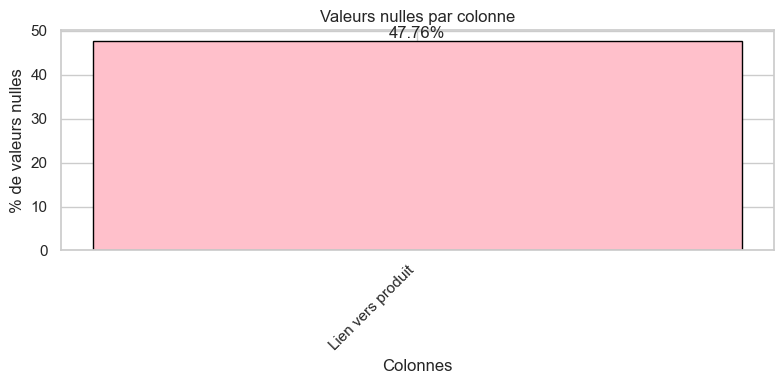

In [89]:
afficherPoucentageNull(Df_Id_Products)


<span style="color:pink">
47.76% sont sans liens donc il faut faire du web scrapping chercher ces produits et ajouter les liens correspandants dans l excel
</span>

<span style="color:#B39DDB ">

## **Analyse de complétude**
</span>

In [90]:
completude = (1 - Df_Id_Products.isnull().mean()) * 100
completude.sort_values()

Lien vers produit     52.238806
Référence Produit    100.000000
Nom Produit          100.000000
dtype: float64


<span style="color:pink">
comletude parfaite pour les References et les Noms mais 1 sur 2 des liens sont manquants comme on l a deja mentionné 

</span>

<span style="color:#B39DDB ">

## **Score global Data Quality**
</span>

In [91]:
score_completude = 1 - Df_Id_Products.isnull().mean().mean()
print (score_completude)

0.8407960199004976



<span style="color:pink">
Tres bon Score Data Quality globalement
</span>

<span style="color:#B39DDB ">

## **Missing Data Matrix**
</span>

<Figure size 600x200 with 0 Axes>

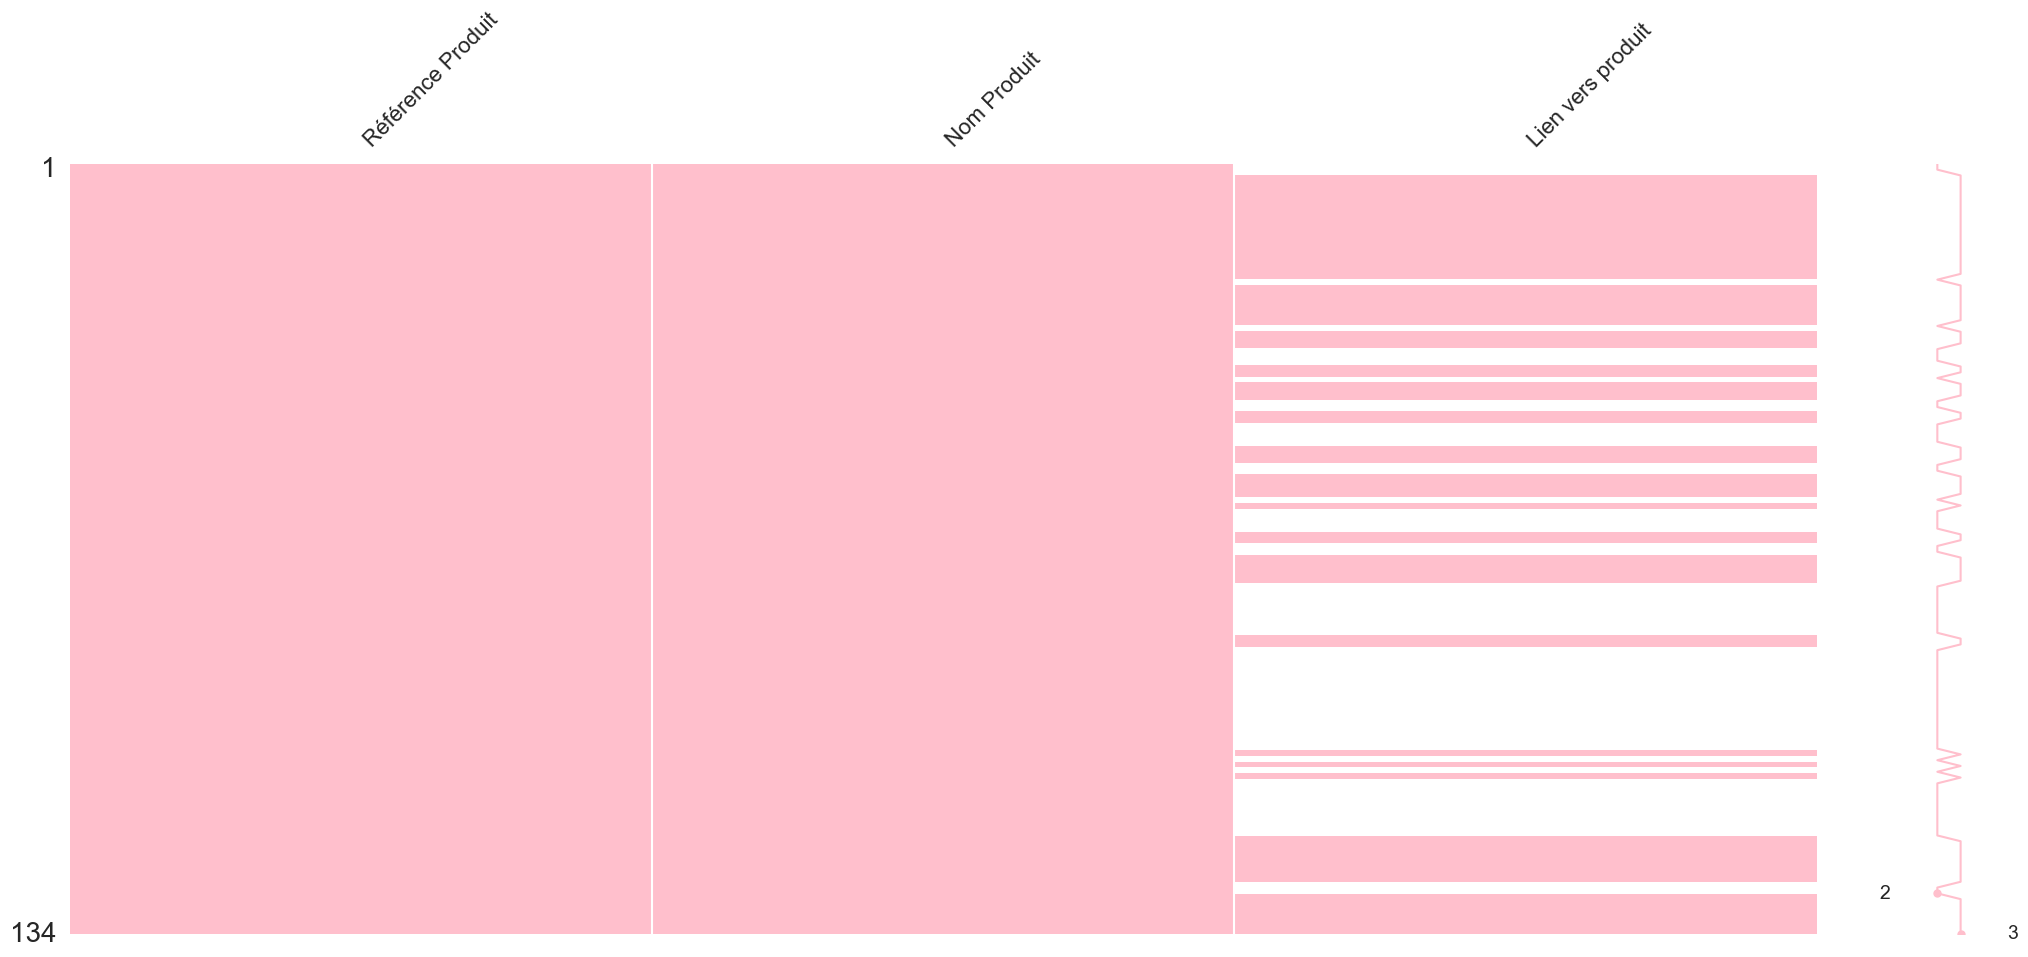

In [92]:
plt.figure(figsize=(6, 2))
msno.matrix(Df_Id_Products, color=(1.0, 0.75, 0.8))
plt.show()

<span style="color:pink">

**Structure du jeu de données**

Le DataFrame contient 3 variables :Référence Produit, Nom Produit,Lien vers produit

Chaque ligne représente un produit unique.
Colonnes **Référence Produit et Nom Produit** Ces deux variables sont entièrement complètes.Aucune valeur manquante n’est observée.
Cela indique un référentiel produit stable et bien structuré, avec des identifiants et des libellés systématiquement renseignés.

**Colonne Lien vers produit** : Cette variable présente un volume important de valeurs manquantes (NaN).

Visuellement, cela se traduit par : des bandes roses (valeurs présentes), alternant avec de larges zones blanches (valeurs absentes). 
Les valeurs affichées à droite de la matrice  le nombre de variables non nulles par ligne
Dans ce contexte :
3 → le produit possède : une référence,un nom,un lien vers le produit.
2 → le produit possède :une référence,un nom,mais pas de lien (NaN).
Aucun cas avec une seule variable renseignée n’est observé.

</span>


<span style="color:#C9A227">

Le manque de liens est plus concentré dans la partie supérieure du DataFrame (premières références), tandis que :
les valeurs présentes apparaissent par blocs plus compacts dans la partie médiane et inférieure.
Cela indique que les produits avec lien ne sont pas répartis aléatoirement, mais regroupés par segments.
</span>

Les valeurs manquantes dans Lien vers produit sont structurelles et attendue


<span style="color:#B39DDB ">

# *valeurs aberrantes*
</span>

L’analyse des valeurs aberrantes n’est pas pertinente pour ce dataset car il ne contient aucune variable quantitative.



<span style="color:#B39DDB ">

# *Analyse des corrélations*
</span>

corr() fonctionne sur les colonnes numériques uniquement et dans ce cas elle sont en object uniquement :Forcer une corrélation ici serait un non-sens analytique


<span style="color:#B39DDB ">

# *Analyse des corrélations*
</span>
inutile car il n y a pas de variable continue : Pas de distribution statistique possible


<span style="color:#B39DDB ">

## **Validité du format des références**
</span>

In [93]:
import pandas as pd

pattern = r'^\s*[A-Z0-9]{1,4}-\d{1,3}-?[A-Z0-9]{1,3}\s*$'

Df_Id_Products['reference_valide'] = (
    Df_Id_Products['Référence Produit']
    .str.match(pattern)
    .fillna(False)
)

# Voir combien sont valides et invalides
print(Df_Id_Products['reference_valide'].value_counts())

# Optionnel : lister toutes les références invalides
valides = Df_Id_Products.loc[Df_Id_Products['reference_valide'], 'Référence Produit']
print("Références valides :", valides.tolist())
invalides = Df_Id_Products.loc[~Df_Id_Products['reference_valide'], 'Référence Produit']
print("Références invalides :", invalides.tolist())



reference_valide
True     121
False     13
Name: count, dtype: int64
Références valides : ['DS-001-SO', 'BP-001-SO', 'CFA-001-SO', 'SGE-001-NA', 'SGE-002-NA', 'SGE-003-NA', 'SO-001-NA', 'SA-001-NA', 'SOV-001-NA', 'SSN-001-2M', 'SSB-001-2M', 'CGO-001-2M', 'DBO-001-2M', 'CGS-001-2M', 'CGS-002-2M', 'BCM-001-KB', 'LPC-001-KB', 'MC-001-KB', 'ZCL-001-KB', 'ZCL-002-KB', 'MCM-001-KB', 'CVC-001-KB', 'TCM-001-KB', 'VTC-001-KB', 'PCM-001-KB', 'PCM-002-KB', 'BVC-001-KB', 'TCC-001-KB', 'BCL-001-RL', 'PSC-001-RL', 'MC-001-RL', 'BCL-002-RL', 'BCL-003-RL', 'BCL-004-RL', 'BCL-005-RL', 'CCL-001-RL', 'BCL-006-RL', 'PSC-002-RL', 'VC-001-RL', 'BC-001-RL', 'BC-002-RL', 'BC-003-RL', 'BC-004-RL', 'BC-005-RL', 'VC-002-RL', 'PML-001-LR', 'MML-001-LR', 'GML-001-LR', 'TBC-001-RL', 'FAV-001-OD', 'CVT-001-OD', 'CVD-001-OD', 'CVC-003-OD', 'VVC-001-OD', 'TBT-001-SS', 'JB-001-SS', 'JM-001-SS', 'JLG-001-SS', 'NBK-001-OSL', 'RP-001-LIB', 'AGM-001-LIB', 'RAG-001-LIB', 'PC-001-RL', 'PC-002-RL', 'PC-003-RL', 'PC-004-RL', '

<span style="color:pink">
on a divisé les references en 2 types valides qui sont sous forme string un numero de serie de 3 a 4 chiffres  
dans invalides on a remarqué la presence de Salaire Mensuel ,Shooting et Transport qui ne peuvent pas etre des references  d'articles artisanaux mis en vente par sougui mais juste une faute reanalysns ces references en excluant ces derniers
</span>

In [94]:
# Références valides → ref_type1
ref_type1 = valides.tolist()

# Références invalides → ref_type2, en excluant certaines à supprimer
exclure = ['Salaire Mensuel', 'Shooting', 'Transport', 'Papier A3 350 G']
ref_type2 = [r for r in invalides.tolist() if r not in exclure]

print("ref_type1  :", ref_type1)
print("ref_type2 :", ref_type2)


ref_type1  : ['DS-001-SO', 'BP-001-SO', 'CFA-001-SO', 'SGE-001-NA', 'SGE-002-NA', 'SGE-003-NA', 'SO-001-NA', 'SA-001-NA', 'SOV-001-NA', 'SSN-001-2M', 'SSB-001-2M', 'CGO-001-2M', 'DBO-001-2M', 'CGS-001-2M', 'CGS-002-2M', 'BCM-001-KB', 'LPC-001-KB', 'MC-001-KB', 'ZCL-001-KB', 'ZCL-002-KB', 'MCM-001-KB', 'CVC-001-KB', 'TCM-001-KB', 'VTC-001-KB', 'PCM-001-KB', 'PCM-002-KB', 'BVC-001-KB', 'TCC-001-KB', 'BCL-001-RL', 'PSC-001-RL', 'MC-001-RL', 'BCL-002-RL', 'BCL-003-RL', 'BCL-004-RL', 'BCL-005-RL', 'CCL-001-RL', 'BCL-006-RL', 'PSC-002-RL', 'VC-001-RL', 'BC-001-RL', 'BC-002-RL', 'BC-003-RL', 'BC-004-RL', 'BC-005-RL', 'VC-002-RL', 'PML-001-LR', 'MML-001-LR', 'GML-001-LR', 'TBC-001-RL', 'FAV-001-OD', 'CVT-001-OD', 'CVD-001-OD', 'CVC-003-OD', 'VVC-001-OD', 'TBT-001-SS', 'JB-001-SS', 'JM-001-SS', 'JLG-001-SS', 'NBK-001-OSL', 'RP-001-LIB', 'AGM-001-LIB', 'RAG-001-LIB', 'PC-001-RL', 'PC-002-RL', 'PC-003-RL', 'PC-004-RL', 'PC-005-RL', 'JEB-001-BF', 'JEB-002-BF', 'E4B-001-BF', 'STB-001-BF', 'PCB-001-

<span style="color:pink">
maintenant qu on a exclu les referrences absurdes comme salaire mensuel shooting et transport regroupons nos prosuits par type en utilisant les references
</span>

<span style="color:#B39DDB ">

## **Type des produits a partir des references**
</span>

<span style="color:#B39DDB ">

## Type des produits a partir des references regroupées par valides ou non
</span>

In [107]:
from collections import defaultdict

def grouper_hiérarchie(ref_list):
    """
    Retourne un dictionnaire hiérarchique :
    {premier_mot: {deuxieme_mot: [références]}}
    """
    hierarchy = defaultdict(lambda: defaultdict(list))
    
    for ref in ref_list:
        ref = ref.strip()          # ✅ suppression des espaces avant/après
        if not ref:                # sécurité : ignorer les chaînes vides
            continue

        parts = ref.split('-')
        key1 = parts[0]
        key2 = parts[1] if len(parts) > 1 else ''
        
        hierarchy[key1][key2].append(ref)
    
    return hierarchy

# Regroupement
grouped_type1 = grouper_hiérarchie(ref_type1)
grouped_type2 = grouper_hiérarchie(ref_type2)

# Affichage clair
def print_hierarchy(grouped):
    for key1, subdict in grouped.items():
        print(f"{key1}:")
        for key2, refs in subdict.items():
            print(f"  {key2}: {refs}")
        print()

print("=== Références valides regroupées ===")
print_hierarchy(grouped_type1)

print("=== Références invalides conservées regroupées ===")
print_hierarchy(grouped_type2)


=== Références valides regroupées ===
DS:
  001: ['DS-001-SO']

BP:
  001: ['BP-001-SO']

CFA:
  001: ['CFA-001-SO']

SGE:
  001: ['SGE-001-NA']
  002: ['SGE-002-NA']
  003: ['SGE-003-NA']

SO:
  001: ['SO-001-NA']

SA:
  001: ['SA-001-NA']

SOV:
  001: ['SOV-001-NA']

SSN:
  001: ['SSN-001-2M']

SSB:
  001: ['SSB-001-2M']

CGO:
  001: ['CGO-001-2M']

DBO:
  001: ['DBO-001-2M']

CGS:
  001: ['CGS-001-2M']
  002: ['CGS-002-2M']

BCM:
  001: ['BCM-001-KB']

LPC:
  001: ['LPC-001-KB']

MC:
  001: ['MC-001-KB', 'MC-001-RL']

ZCL:
  001: ['ZCL-001-KB']
  002: ['ZCL-002-KB']

MCM:
  001: ['MCM-001-KB']

CVC:
  001: ['CVC-001-KB']
  003: ['CVC-003-OD']

TCM:
  001: ['TCM-001-KB']

VTC:
  001: ['VTC-001-KB']

PCM:
  001: ['PCM-001-KB']
  002: ['PCM-002-KB']

BVC:
  001: ['BVC-001-KB']
  002: ['BVC-002-SO']

TCC:
  001: ['TCC-001-KB']

BCL:
  001: ['BCL-001-RL']
  002: ['BCL-002-RL']
  003: ['BCL-003-RL']
  004: ['BCL-004-RL']
  005: ['BCL-005-RL']
  006: ['BCL-006-RL']

PSC:
  001: ['PSC-001-R


<span style="color:pink">

**Les références valides suivent un format normalisé**

**Préfixe** : identifie la gamme, catégorie ou famille produit(ex. DS, BP, CFA, SGE, BCL, PC, ED, etc.)

**Numéro** : identifiant incrémental au sein de la gamme(001, 002, 003, …)

**Suffixe** : variante ou attribut produit(SO, NA, KB, RL, BF, FP, RES, etc.)
logique de codification industrielle, cohérente et réutilisable.
Certaines gammes ne contiennent qu’une seule référence
→ ex. DS-001-SO, BP-001-SO
➜ produits uniques ou gammes très restreintes.

D’autres gammes présentent :
plusieurs numéros (SGE, CGS, PCM, ED, SPR, PC, etc.),ou plusieurs variantes pour un même numéro (ex. MC-001-KB et MC-001-RL, VVC-001-OD et VVC-001-SMC).
Cela reflète :soit des variantes de matière / parfum / format,soit des déclinaisons commerciales d’un même produit.
</span>


<span style="color:pink">

**Les références qui ne respectent aucun  schéma standard, mais ont été volontairement conservées.**

Types d’anomalies observées

Références incomplètes ex : BA ,LIV-P ,LMH-HA

Formats hétérogènes / texte libre : COU-CUIR-FOUTA-002 , MUG-BOH ,SDB-PPH
</span>

<span style="color:#B39DDB ">

## Type des produits a partir des references non regroupées selon la validité
</span>

In [108]:
# --- Étape 1 : créer les hiérarchies séparées ---
grouped_type1 = grouper_hiérarchie(ref_type1)
grouped_type2 = grouper_hiérarchie(ref_type2)

# --- Étape 2 : fusionner les deux hiérarchies ---
merged_hierarchy = fusionner_hierarchie(grouped_type1, grouped_type2)
types = list(merged_hierarchy.keys())
print("Nombre total de types :", len(types))
print("Liste des types :", types)

# --- Étape 3 : afficher le résumé par type et sous-type ---
for t in merged_hierarchy:
    subdict = merged_hierarchy[t]
    total_refs = sum(len(refs) for refs in subdict.values())
    print(f"{t}: {total_refs} référence{'s' if total_refs > 1 else ''}")
    for st, refs in subdict.items():
        print(f"  {st}: {len(refs)} référence{'s' if len(refs) > 1 else ''} → {refs}")
    print()


Nombre total de types : 84
Liste des types : ['DS', 'BP', 'CFA', 'SGE', 'SO', 'SA', 'SOV', 'SSN', 'SSB', 'CGO', 'DBO', 'CGS', 'BCM', 'LPC', 'MC', 'ZCL', 'MCM', 'CVC', 'TCM', 'VTC', 'PCM', 'BVC', 'TCC', 'BCL', 'PSC', 'CCL', 'VC', 'BC', 'PML', 'MML', 'GML', 'TBC', 'FAV', 'CVT', 'CVD', 'VVC', 'TBT', 'JB', 'JM', 'JLG', 'NBK', 'RP', 'AGM', 'RAG', 'PC', 'JEB', 'E4B', 'STB', 'PCB', 'AS', 'PCC', 'PMC', 'ED', 'VV', 'DV', 'VB', 'CFV', 'VL', 'SPR', 'PDE', 'BPB', 'LB', 'SMB', 'BB', 'TB', 'P', 'PAC', 'SCA', 'POC', 'SRO', 'SCC', 'STC', 'JAV', 'MFB', 'POB', 'LIV', 'LMH', 'BA', 'TSC', 'SDB', 'MUG', 'COU', 'SCO', 'FOT']
DS: 1 référence
  001: 1 référence → ['DS-001-SO']

BP: 1 référence
  001: 1 référence → ['BP-001-SO']

CFA: 1 référence
  001: 1 référence → ['CFA-001-SO']

SGE: 3 références
  001: 1 référence → ['SGE-001-NA']
  002: 1 référence → ['SGE-002-NA']
  003: 1 référence → ['SGE-003-NA']

SO: 1 référence
  001: 1 référence → ['SO-001-NA']

SA: 1 référence
  001: 1 référence → ['SA-001-NA']



<span style="color:pink">
en total on 84 types de produits artisanaux
</span>

<span style="color:#B39DDB ">

## **Validité des liens (URL)**
</span>

In [103]:
import requests

def url_est_valide(url):
    try:
        response = requests.head(url, allow_redirects=True, timeout=5)
        return response.status_code == 200
    except:
        return False

# Appliquer à ton DataFrame
Df_Id_Products['url_valide'] = Df_Id_Products['Lien vers produit'].apply(url_est_valide)

print(Df_Id_Products['url_valide'].value_counts())
# Afficher uniquement les liens non valides et non nuls
liens_non_valides = Df_Id_Products[
    (Df_Id_Products['url_valide'] == False) & 
    (Df_Id_Products['Lien vers produit'].notna())
]

print(liens_non_valides[['Lien vers produit']])


url_valide
False    3
True     1
Name: count, dtype: int64
                                   Lien vers produit
1  https://sougui.tn/product/carafe-didon-premium...
2         Cruche en céramique circulaire avec motifs
3  Couffin artisanal en fibre végétale – Anses cu...


<span style="color:pink">


**Cruche en céramique circulaire avec motifs et  Couffin artisanal en fibre végétale**
presentent en effet un probleme leurs liens marchent a partir de l excel mais ne marchent pas en cas ou on veut copier coller le lien a d autres personnes car leur structures est incorrecte 



et pour le lien
**https://sougui.tn/product/carafe-didon-premium** sa methode get n a pas retourné 200 succés elle a retourné 404 error donc il faut corriger ce lien ou peut etre le produit n es t plus disponible donc il ne feut plus le mettre dans les fichiers excels qui concernent les produits

</span>

<span style="color:pink">
assurons nous que parmis les liens de forme  valides carafe didon est le seule qui ne retourne pas 200 succés
</span>

In [ ]:
import requests
import pandas as pd

# Exemple DataFrame
Df_Id_Products = pd.DataFrame({
    'Lien vers produit': [
        'https://sougui.tn/product/mathred-coupe-a-pied-martelee-en-cuivre-argente/',
        'https://sougui.tn/product/carafe-didon-premium-12345/',
        'Cruche en céramique circulaire avec motifs',
        'Couffin artisanal en fibre végétale – Anses curvées'
    ]
})

# Fonction pour tester si un lien existe (HTTP 200)
def url_est_valide(url):
    try:
        response = requests.head(url, allow_redirects=True, timeout=5)
        return response.status_code == 200
    except:
        return False

# 1️⃣ Ne garder que les vraies URLs
Df_Id_Products['est_url'] = Df_Id_Products['Lien vers produit'].str.startswith('http', na=False)

# 2️⃣ Vérifier la validité uniquement sur ces URLs
Df_Id_Products.loc[Df_Id_Products['est_url'], 'url_valide'] = Df_Id_Products.loc[Df_Id_Products['est_url'], 'Lien vers produit'].apply(url_est_valide)

# 3️⃣ Afficher uniquement les liens morts
liens_non_valides = Df_Id_Products[
    (Df_Id_Products['est_url']) & 0
    (Df_Id_Products['url_valide'] == False)
]

print("Liens non valides :")
print(liens_non_valides[['Lien vers produit']])


Liens non valides :
                                   Lien vers produit
1  https://sougui.tn/product/carafe-didon-premium...


<span style="color:pink">
oui en effet le lien carafe didon est le seul lien de forme valide qui ne retourne pas de succés


on doit supprimer cet article ou remplacer le lien
</span>

<span style="color:#B39DDB ">

## **Problèmes identifiés**
</span>


<span style="color:#B39DDB ">

## **Recommandations**
</span>